In [1]:
pip install owslib rasterio geopandas pandas numpy pillow requests scipy reverse_geocoder #do not need to run this line of code

     ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
     ---------------------------------------- 2.2/2.2 MB 25.1 MB/s  0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for reverse_geocoder: filename=reverse_geocoder-1.5.1-py3-none-any.whl size=2268124 sha256=3aa881dbc438db68e270b5b3cc218901151dc43583af0c1bceb52c1b870e6d17
  Stored in directory: c:\users\15345\appdata\local\pip\cache\wheels\17\3c\41\2bc89719586c2a5c53e9a527daa76a968a1288315c1ae2d904
Successfully built reverse_geocoder
Note: you may need to restart the kernel to use updated packages.


In [18]:
pip install earthengine-api

   ---------------------------------------- 0.0/15.2 MB ? eta -:--:--
   -------------- ------------------------- 5.5/15.2 MB 28.0 MB/s eta 0:00:01
   ---------------------------------------  15.2/15.2 MB 38.3 MB/s eta 0:00:01
   ---------------------------------------- 15.2/15.2 MB 34.2 MB/s  0:00:00
   ---------------------------------------- 0.0/3.8 MB ? eta -:--:--
   ---------------------------------------- 3.8/3.8 MB 75.6 MB/s  0:00:00

   -- -------------------------------------  1/16 [pyasn1]
   -- -------------------------------------  1/16 [pyasn1]
   ----- ----------------------------------  2/16 [proto-plus]
   ---------- -----------------------------  4/16 [googleapis-common-protos]
   ---------- -----------------------------  4/16 [googleapis-common-protos]
   ---------- -----------------------------  4/16 [googleapis-common-protos]
   --------------- ------------------------  6/16 [pyasn1-modules]
   --------------- ------------------------  6/16 [pyasn1-modules]
   ----

In [1]:
import ee



# 1. Trigger the authentication flow
ee.Authenticate()

Enter verification code:  4/1AeoWuM_pmzV0AhVjqIwPe7wkhcn_coI0hawM7JDWJn-79DD5BQgYk-57d1Y



Successfully saved authorization token.


In [5]:
import ee

ee.Authenticate()
ee.Initialize(project='ee-bawan')  # try this or check your actual project ID

states = ee.FeatureCollection("TIGER/2018/States")
iowa = states.filter(ee.Filter.eq('NAME', 'Iowa')).geometry()
kansas = states.filter(ee.Filter.eq('NAME', 'Kansas')).geometry()
texas = states.filter(ee.Filter.eq('NAME', 'Texas')).geometry()

start_date = '2023-01-01'
end_date = '2023-12-31'

modis_ndvi = ee.ImageCollection('MODIS/061/MOD13A2') \
    .filterDate(start_date, end_date) \
    .select('NDVI')

modis_lst = ee.ImageCollection('MODIS/061/MOD11A2') \
    .filterDate(start_date, end_date) \
    .select('LST_Day_1km')


In [6]:
def get_monthly_stats(collection, geometry, state_name, variable):
    results = []
    for month in range(1, 13):
        monthly = collection.filter(ee.Filter.calendarRange(month, month, 'month'))
        mean_val = monthly.mean().reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=geometry,
            scale=1000,
            maxPixels=1e9
        ).getInfo()
        results.append({
            'state': state_name,
            'month': month,
            variable: list(mean_val.values())[0]
        })
    return results

# Extract NDVI
ndvi_data = []
ndvi_data += get_monthly_stats(modis_ndvi, iowa, 'Iowa', 'NDVI')
ndvi_data += get_monthly_stats(modis_ndvi, kansas, 'Kansas', 'NDVI')
ndvi_data += get_monthly_stats(modis_ndvi, texas, 'Texas', 'NDVI')

# Extract LST
lst_data = []
lst_data += get_monthly_stats(modis_lst, iowa, 'Iowa', 'LST')
lst_data += get_monthly_stats(modis_lst, kansas, 'Kansas', 'LST')
lst_data += get_monthly_stats(modis_lst, texas, 'Texas', 'LST')

# Merge and save
import pandas as pd
ndvi_df = pd.DataFrame(ndvi_data)
lst_df = pd.DataFrame(lst_data)
df = ndvi_df.merge(lst_df, on=['state', 'month'])

# Convert LST from Kelvin to Celsius
df['LST'] = df['LST'] * 0.02 - 273.15
# Scale NDVI
df['NDVI'] = df['NDVI'] * 0.0001

print(df)
#df.to_csv('modis_iowa_kansas_texas.csv', index=False)

     state  month      NDVI        LST
0     Iowa      1  0.083127  -4.967852
1     Iowa      2  0.155028   2.316780
2     Iowa      3  0.231074   9.864653
3     Iowa      4  0.302877  24.461662
4     Iowa      5  0.417341  30.620872
5     Iowa      6  0.700853  32.594722
6     Iowa      7  0.836316  27.327899
7     Iowa      8  0.792806  27.609835
8     Iowa      9  0.497998  26.429703
9     Iowa     10  0.353061  16.655985
10    Iowa     11  0.316010   9.693968
11    Iowa     12  0.275512   3.522264
12  Kansas      1  0.226909   5.280919
13  Kansas      2  0.245365  10.966877
14  Kansas      3  0.277149  18.762392
15  Kansas      4  0.331772  29.091964
16  Kansas      5  0.480761  32.266788
17  Kansas      6  0.564300  33.175454
18  Kansas      7  0.600652  34.326555
19  Kansas      8  0.544018  35.013354
20  Kansas      9  0.447775  31.757197
21  Kansas     10  0.363234  22.737140
22  Kansas     11  0.338506  14.201647
23  Kansas     12  0.321110   7.337210
24   Texas      1  0.3399

In [7]:
import ee
import pandas as pd

ee.Authenticate()
ee.Initialize(project='ee-bawan')

states = ee.FeatureCollection("TIGER/2018/States")

geometries = {
    "Iowa": states.filter(ee.Filter.eq("NAME", "Iowa")).geometry(),
    "Kansas": states.filter(ee.Filter.eq("NAME", "Kansas")).geometry(),
    "Texas": states.filter(ee.Filter.eq("NAME", "Texas")).geometry(),
}

start_date = "2023-01-01"
end_date = "2023-12-31"

modis_ndvi = (
    ee.ImageCollection("MODIS/061/MOD13A2")
    .filterDate(start_date, end_date)
    .select("NDVI")
)

modis_lst = (
    ee.ImageCollection("MODIS/061/MOD11A2")
    .filterDate(start_date, end_date)
    .select(["LST_Day_1km", "LST_Night_1km"])
)

precip = (
    ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")
    .filterDate(start_date, end_date)
    .select("precipitation")
)


def get_monthly_mean(collection, geometry, state_name, band_name, output_name, scale):
    results = []

    for month in range(1, 13):
        monthly = collection.filter(
            ee.Filter.calendarRange(month, month, "month")
        )

        mean_dict = monthly.mean().reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=geometry,
            scale=scale,
            maxPixels=1e9,
        ).getInfo()

        results.append({
            "state": state_name,
            "month": month,
            output_name: mean_dict.get(band_name)
        })

    return results


def get_monthly_precip_sum(collection, geometry, state_name, band_name, output_name, scale):
    results = []

    for month in range(1, 13):
        monthly = collection.filter(
            ee.Filter.calendarRange(month, month, "month")
        )

        precip_dict = monthly.sum().reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=geometry,
            scale=scale,
            maxPixels=1e9,
        ).getInfo()

        results.append({
            "state": state_name,
            "month": month,
            output_name: precip_dict.get(band_name)
        })

    return results


ndvi_data = []
lst_day_data = []
lst_night_data = []
precip_data = []

for state_name, geometry in geometries.items():
    ndvi_data += get_monthly_mean(
        modis_ndvi,
        geometry,
        state_name,
        band_name="NDVI",
        output_name="NDVI",
        scale=1000,
    )

    lst_day_data += get_monthly_mean(
        modis_lst,
        geometry,
        state_name,
        band_name="LST_Day_1km",
        output_name="LST_Day",
        scale=1000,
    )

    lst_night_data += get_monthly_mean(
        modis_lst,
        geometry,
        state_name,
        band_name="LST_Night_1km",
        output_name="LST_Night",
        scale=1000,
    )

    precip_data += get_monthly_precip_sum(
        precip,
        geometry,
        state_name,
        band_name="precipitation",
        output_name="Precipitation",
        scale=5000,
    )


ndvi_df = pd.DataFrame(ndvi_data)
lst_day_df = pd.DataFrame(lst_day_data)
lst_night_df = pd.DataFrame(lst_night_data)
precip_df = pd.DataFrame(precip_data)

df = (
    ndvi_df
    .merge(lst_day_df, on=["state", "month"], how="left")
    .merge(lst_night_df, on=["state", "month"], how="left")
    .merge(precip_df, on=["state", "month"], how="left")
)

# Scale NDVI
df["NDVI"] = df["NDVI"] * 0.0001

# Convert MODIS LST from scaled Kelvin to Celsius
df["LST_Day"] = df["LST_Day"] * 0.02 - 273.15
df["LST_Night"] = df["LST_Night"] * 0.02 - 273.15

print(df)

# df.to_csv("modis_iowa_kansas_texas_with_lst_night_precip.csv", index=False)

     state  month      NDVI    LST_Day  LST_Night  Precipitation
0     Iowa      1  0.083127  -4.967852 -11.546942      39.102810
1     Iowa      2  0.155028   2.316780  -5.784549      42.019556
2     Iowa      3  0.231074   9.864653  -3.871737      41.107000
3     Iowa      4  0.302877  24.461662   3.177979      54.486248
4     Iowa      5  0.417341  30.620872  10.303910      61.247511
5     Iowa      6  0.700853  32.594722  16.738317      66.587874
6     Iowa      7  0.836316  27.327899  17.692191      83.285112
7     Iowa      8  0.792806  27.609835  18.632532      72.217339
8     Iowa      9  0.497998  26.429703  13.084526      55.587871
9     Iowa     10  0.353061  16.655985   6.092787      69.752774
10    Iowa     11  0.316010   9.693968  -2.213111      14.646664
11    Iowa     12  0.275512   3.522264  -4.322368      35.370768
12  Kansas      1  0.226909   5.280919  -6.515615      25.794126
13  Kansas      2  0.245365  10.966877  -3.247409      23.196587
14  Kansas      3  0.2771

In [8]:
df.isna().sum()

state            0
month            0
NDVI             0
LST_Day          0
LST_Night        0
Precipitation    0
dtype: int64

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Optional: add crop labels
crop_map = {
    "Iowa": "Corn",
    "Kansas": "Wheat",
    "Texas": "Cotton"
}

df["state_crop"] = df["state"].map(lambda x: f"{x} ({crop_map[x]})")

In [11]:
df

,state,month,NDVI,LST_Day,LST_Night,Precipitation,state_crop
0,Iowa,1,0.083127,-4.967852,-11.546942,39.102810,Iowa (Corn)
1,Iowa,2,0.155028,2.316780,-5.784549,42.019556,Iowa (Corn)
2,Iowa,3,0.231074,9.864653,-3.871737,41.107000,Iowa (Corn)
3,Iowa,4,0.302877,24.461662,3.177979,54.486248,Iowa (Corn)
4,Iowa,5,0.417341,30.620872,10.303910,61.247511,Iowa (Corn)
5,Iowa,6,0.700853,32.594722,16.738317,66.587874,Iowa (Corn)
6,Iowa,7,0.836316,27.327899,17.692191,83.285112,Iowa (Corn)
7,Iowa,8,0.792806,27.609835,18.632532,72.217339,Iowa (Corn)
8,Iowa,9,0.497998,26.429703,13.084526,55.587871,Iowa (Corn)
9,Iowa,10,0.353061,16.655985,6.092787,69.752774,Iowa (Corn)


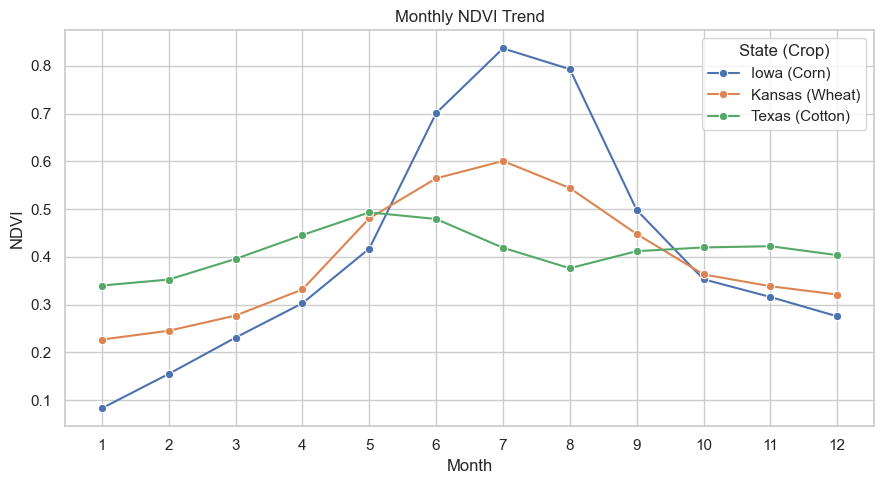

In [14]:
plt.figure(figsize=(9, 5))

sns.lineplot(
    data=df,
    x="month",
    y="NDVI",
    hue="state_crop",
    marker="o"
)

plt.title("Monthly NDVI Trend")
plt.xlabel("Month")
plt.ylabel("NDVI")
plt.xticks(range(1, 13))
plt.legend(title="State (Crop)")
plt.tight_layout()
plt.show()

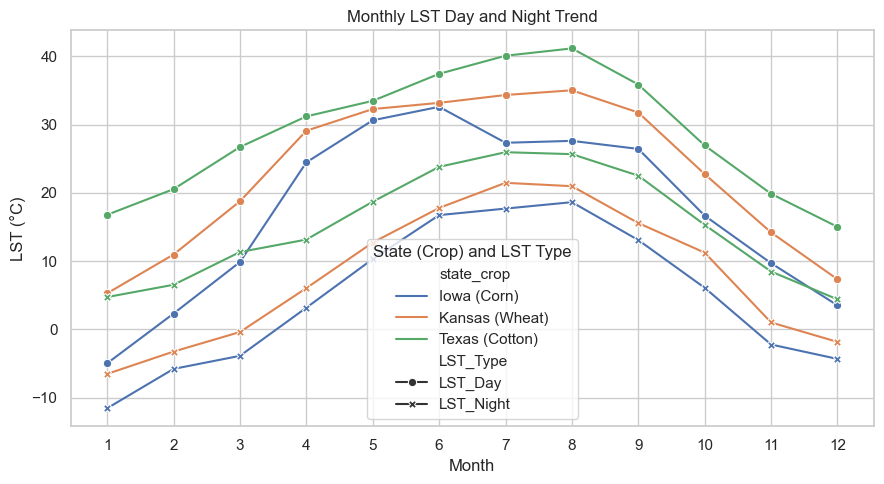

In [18]:
lst_long = df.melt(
    id_vars=["state", "month", "state_crop"],
    value_vars=["LST_Day", "LST_Night"],
    var_name="LST_Type",
    value_name="LST_Celsius"
)

plt.figure(figsize=(9, 5))

sns.lineplot(
    data=lst_long,
    x="month",
    y="LST_Celsius",
    hue="state_crop",
    style="LST_Type",
    markers=True,
    dashes=False
)

plt.title("Monthly LST Day and Night Trend")
plt.xlabel("Month")
plt.ylabel("LST (°C)")
plt.xticks(range(1, 13))
plt.legend(title="State (Crop) and LST Type")
plt.tight_layout()
plt.show()

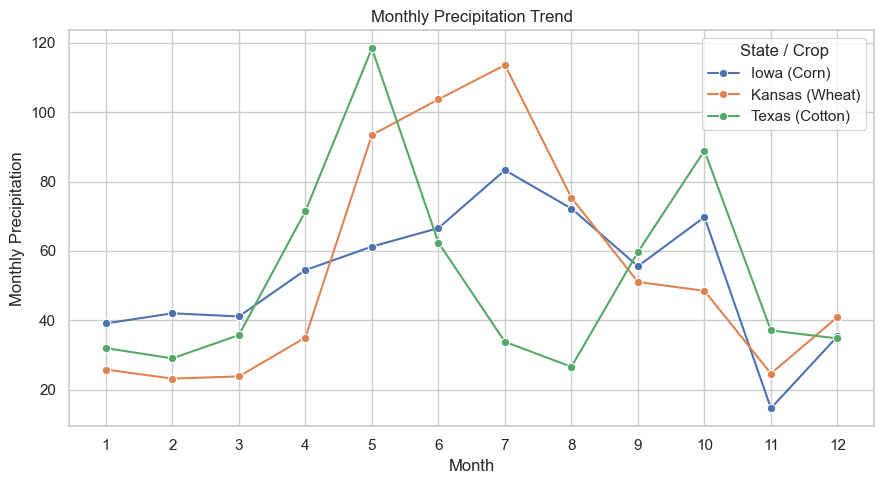

In [19]:
plt.figure(figsize=(9, 5))

sns.lineplot(
    data=df,
    x="month",
    y="Precipitation",
    hue="state_crop",
    marker="o"
)

plt.title("Monthly Precipitation Trend")
plt.xlabel("Month")
plt.ylabel("Monthly Precipitation")
plt.xticks(range(1, 13))
plt.legend(title="State / Crop")
plt.tight_layout()
plt.show()

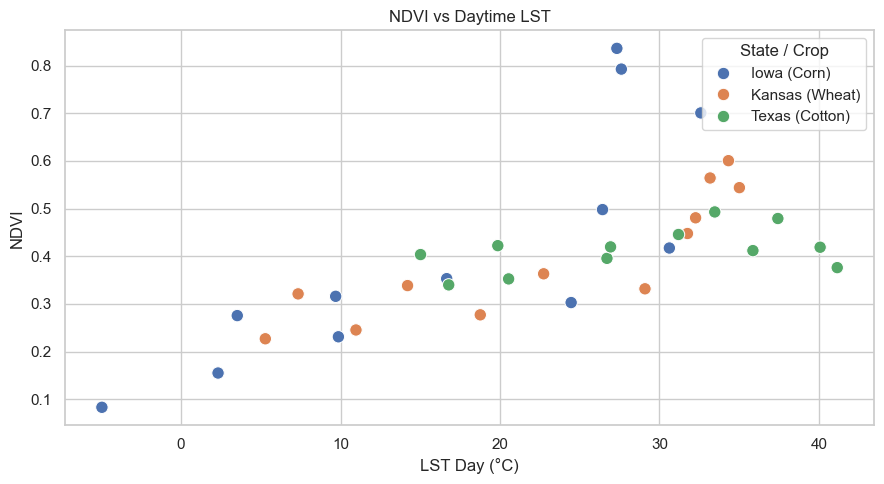

In [21]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x="LST_Day",
    y="NDVI",
    hue="state_crop",
    s=80
)

plt.title("NDVI vs Daytime LST")
plt.xlabel("LST Day (°C)")
plt.ylabel("NDVI")
plt.legend(title="State (Crop)")
plt.tight_layout()
plt.show()

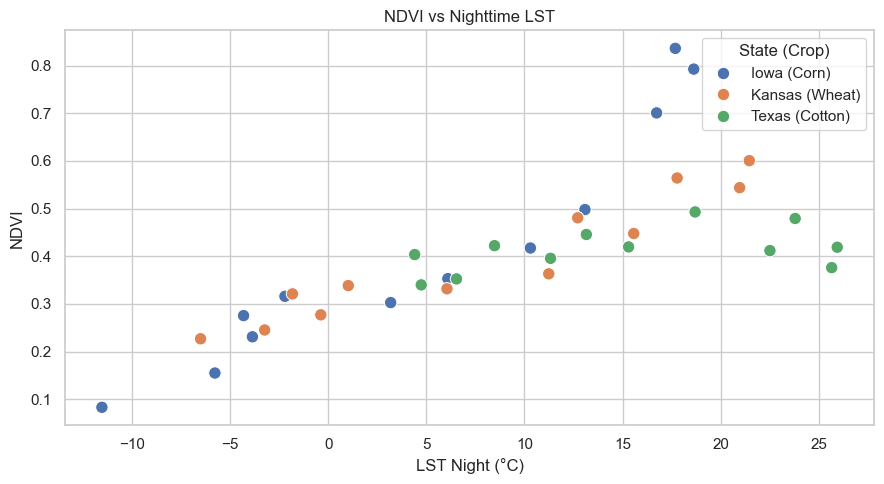

In [25]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x="LST_Night",
    y="NDVI",
    hue="state_crop",
    s=80
)

plt.title("NDVI vs Nighttime LST")
plt.xlabel("LST Night (°C)")
plt.ylabel("NDVI")
plt.legend(title="State (Crop)")
plt.tight_layout()
plt.show()

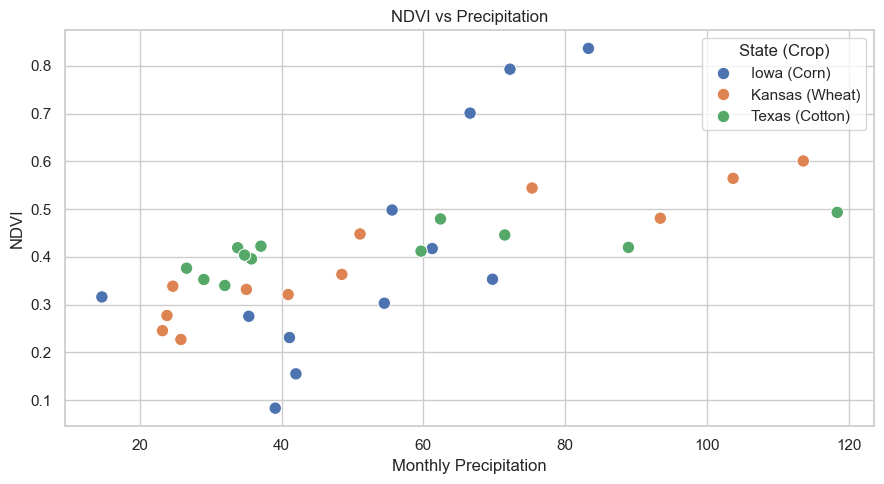

In [26]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x="Precipitation",
    y="NDVI",
    hue="state_crop",
    s=80
)

plt.title("NDVI vs Precipitation")
plt.xlabel("Monthly Precipitation")
plt.ylabel("NDVI")
plt.legend(title="State (Crop)")
plt.tight_layout()
plt.show()

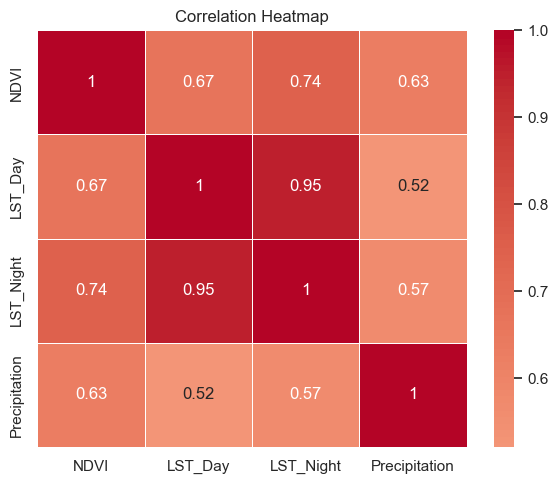

In [27]:
corr_cols = ["NDVI", "LST_Day", "LST_Night", "Precipitation"]

corr = df[corr_cols].corr()

plt.figure(figsize=(6, 5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()